In [16]:
import json
import re
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt

EVAL_DIRS = {
    "30B RM": Path("/tmp/instance_storage/eval_results"),
    "235B RM": Path("/tmp/instance_storage/235b_eval_results"),
}
BASELINE_PREFIX = "instance_storage__qwen3-30B-A3B"

# ── 1. Load, parse, dedup, build curves ────────────────────────────────


def load_and_build_curves(eval_dir: Path, baseline_prefix: str) -> dict:
    raw = []
    for f in sorted(eval_dir.glob("*.json")):
        with open(f) as fh:
            d = json.load(fh)
        raw.append(d)

    # Parse and dedup
    best = {}
    for d in raw:
        meta = d["metadata"]
        ckpt_name = meta["checkpoint_name"]
        ts = meta["timestamp"]
        pak = d["pass_at_k"]

        m = re.match(r"^(.+)__iter_(\d+)$", ckpt_name)
        if m:
            model, iter_num = m.group(1), int(m.group(2))
        else:
            model, iter_num = ckpt_name, None

        key = (model, iter_num)
        if key not in best or ts > best[key][0]:
            best[key] = (ts, pak)

    # Baseline
    baseline_key = (baseline_prefix, None)
    best[baseline_key][1] if baseline_key in best else {k: 0.0 for k in ["1", "2", "3", "4"]}

    # Build curves
    model_points = defaultdict(list)
    for (model, iter_num), (ts, pak) in best.items():
        if iter_num is not None:
            model_points[model].append((iter_num + 1, pak))

    curves = {}
    for model, pts in model_points.items():
        if "step_filter" in model:
            continue
        pts.sort()
        steps = [s for s, _ in pts]
        curves[model] = {"steps": steps}
        for k in ["1", "2", "3", "4"]:
            curves[model][f"pass@{k}"] = [p[k] for _, p in pts]

    return curves


all_curves = {}  # rm_label -> curves dict
for label, path in EVAL_DIRS.items():
    if "step_filter" in label:
        continue
    all_curves[label] = load_and_build_curves(path, BASELINE_PREFIX)
    n_models = len(all_curves[label])
    for model, c in all_curves[label].items():
        print(f"  {label} | {model}: steps={c['steps']}")

  30B RM | batch_0_200_step_no_filter_hf: steps=[20, 40, 60, 80, 100, 120, 140, 160, 180, 200]
  235B RM | batch_0_200_step_no_filter_hf: steps=[20, 40, 60, 80, 100, 120, 140, 160, 180, 200]


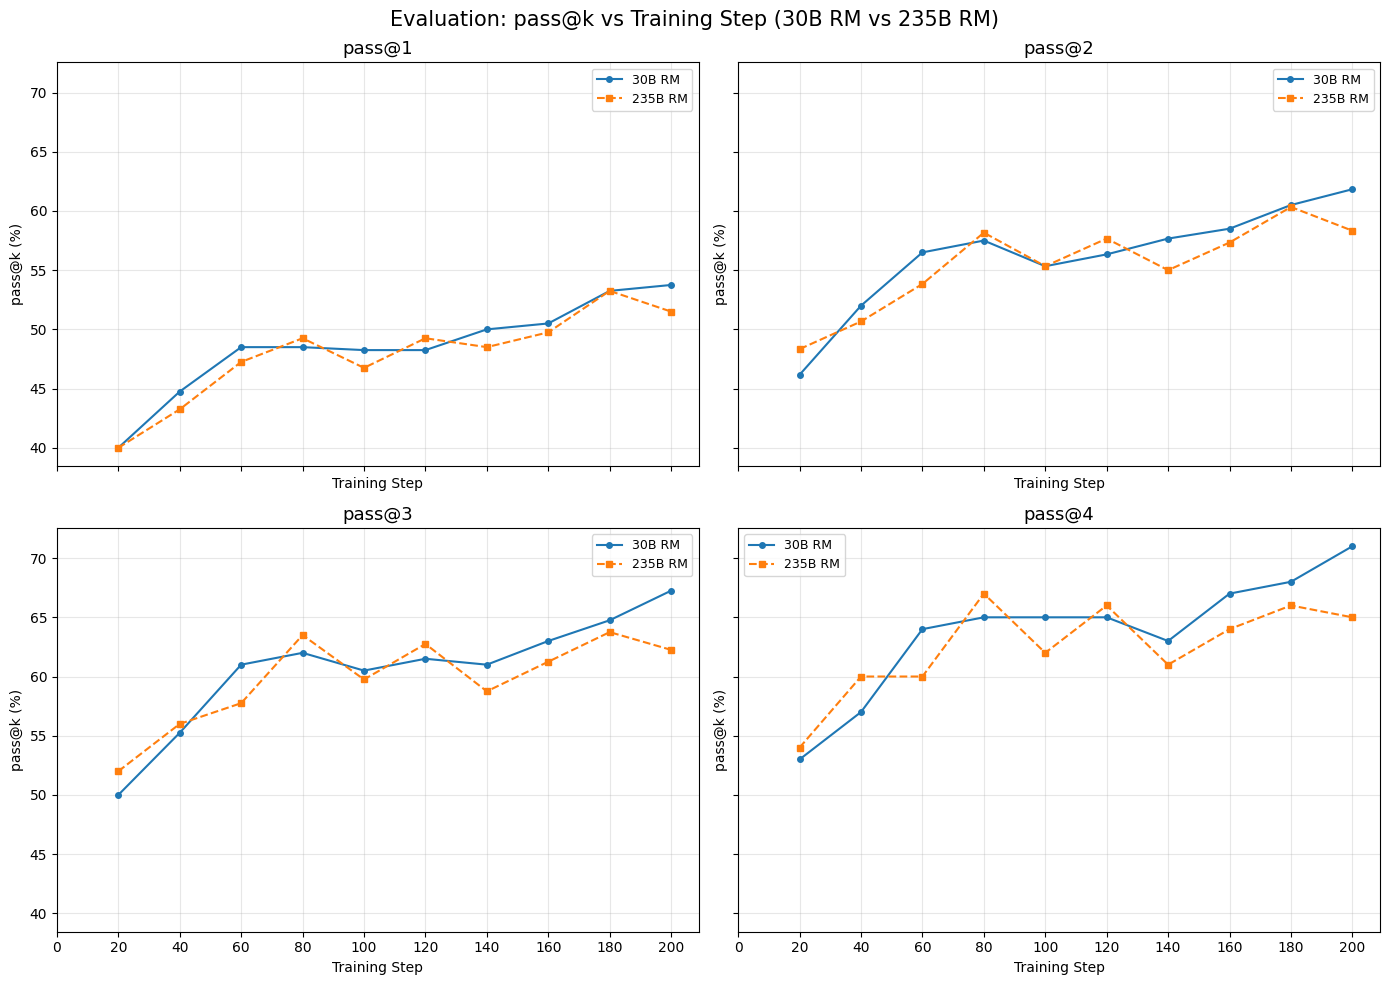

Saved to /tmp/instance_storage/eval_results/pass_at_k_compare_rm.png


In [17]:
# ── 2. Plot pass@1..4 — one line per RM ──────────────────────────────


def short_name(model: str) -> str:
    return model.replace("_hf", "").replace("batch_0_200_step_", "")


COLORS = {"30B RM": "tab:blue", "235B RM": "tab:orange"}
MARKERS = {"30B RM": "o", "235B RM": "s"}
STYLES = {"30B RM": "-", "235B RM": "--"}

# Collect all steps across both RMs for x-axis range
all_steps = []
for curves in all_curves.values():
    for c in curves.values():
        all_steps.extend(c["steps"])
max_step = max(all_steps) if all_steps else 200

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
fig.suptitle("Evaluation: pass@k vs Training Step (30B RM vs 235B RM)", fontsize=15, y=0.98)

for idx, k in enumerate(["1", "2", "3", "4"]):
    ax = axes[idx // 2][idx % 2]
    for rm_label, curves in all_curves.items():
        for model, c in sorted(curves.items()):
            ax.plot(
                c["steps"],
                [v * 100 for v in c[f"pass@{k}"]],
                marker=MARKERS[rm_label],
                markersize=4,
                linewidth=1.5,
                linestyle=STYLES[rm_label],
                color=COLORS[rm_label],
                label=rm_label,
            )
    ax.set_title(f"pass@{k}", fontsize=13)
    ax.set_xlabel("Training Step")
    ax.set_ylabel("pass@k (%)")
    ax.set_xticks(range(0, max_step + 1, 20))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.savefig("/tmp/instance_storage/eval_results/pass_at_k_compare_rm.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to /tmp/instance_storage/eval_results/pass_at_k_compare_rm.png")